In [2]:
import sys
from pathlib import Path

# Go to project root (REALTIMEFRAUDDETECTION)
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from src.models.IsolationForest import IsolationForestModel
from src.models.SelfOrganizingMap import SOMModel
from src.models.AutoEncoder import AutoEncoderModel
from src.training.train import trainmodel

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026-03-17 10:51:05.341540: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 10:51:05.720288: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 10:51:07.824143: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("../data/dataset_PFE_CDM_complet.csv")
df.shape

(1100000, 17)

In [7]:
df['Time']=pd.to_datetime(df['Time'])
df['Age']=df['Age'].astype(int)

df['Hour']=df['Time'].dt.hour
df['Date']=df['Time'].dt.date

In [8]:
df.sort_values(['Account Number','Time'],inplace=True)
df['rank']=df.groupby("Account Number")['Time'].rank(method='first',pct=True)

# Feature Engineering

In [9]:
from src.features.TimeFeatures import ComputeTimeFeatures
from src.features.CatEntropy import ComputeCatEntropy
from src.features.CatFreq import ComputeCatFreq
from src.preprocessing.TrainTestSplit import split

In [10]:
df=ComputeTimeFeatures(df)
df=ComputeCatEntropy(df)
df=ComputeCatFreq(df)

In [11]:
df=df[['Age','rank',
       'LogAmount', 'MovingAvg','MovingStd', 'LogTimeDiff','Hour',
       'TransactionTypeEntropy', 'ChannelEntropy','CardTypeEntropy', 'MerchandEntropy', 'CountryEntropy', 'CityEntropy',
       'TransactionTypeFreq','ChannelFreq','CardTypeFreq', 'MerchandFreq', 'CountryFreq','CityFreq']]

traindf,testdf=split(df)

In [12]:
traindf.shape

(879198, 18)

# Min Mean Models

In [13]:
meaniso=IsolationForestModel(nestimators=111,maxsamples=0.62,contamination=0.01)
meansom=SOMModel(x=20,y=20,sigma=1.35,learning_rate=0.14)
meanae=AutoEncoderModel(lr=0.001,batchsize=128)


trainmodel(meaniso,testdf)
trainmodel(meansom,testdf)
trainmodel(meanae,testdf)

2026-03-17 10:51:24.487754: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 7.7601 - val_loss: 0.3015
Epoch 2/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1794 - val_loss: 0.1510
Epoch 3/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1252 - val_loss: 0.0915
Epoch 4/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0586 - val_loss: 0.0509
Epoch 5/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0433 - val_loss: 0.0431
Epoch 6/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0352 - val_loss: 0.0341
Epoch 7/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0298 - val_loss: 0.0305
Epoch 8/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0283 - val_loss: 0.0291
Epoch 9/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0278 - val_loss: 0.0295
Epoch 10/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0275 - val_loss: 0.0291
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


{'score_mean': 0.02744802543063132,
 'score_std': 0.03814411520086904,
 'score_skew': 6.067854726977036,
 'score_p95': 0.0720195058436838,
 'score_p99': 0.1887378156287923,
 'tailsep': 0.13404944672332866}

# Max Std Models

In [14]:
stdiso=IsolationForestModel(nestimators=244,maxsamples=0.64,contamination=0.04)
stdsom=SOMModel(x=8,y=5,sigma=1.96,learning_rate=0.25)
stdae=AutoEncoderModel(lr=0.0001,batchsize=256)


trainmodel(stdiso,testdf)
trainmodel(stdsom,testdf)
trainmodel(stdae,testdf)

Epoch 1/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 91.8666 - val_loss: 14.2460
Epoch 2/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.9590 - val_loss: 4.4647
Epoch 3/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.2638 - val_loss: 4.2334
Epoch 4/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.0170 - val_loss: 3.9222
Epoch 5/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.5231 - val_loss: 3.1353
Epoch 6/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.2582 - val_loss: 1.4917
Epoch 7/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9751 - val_loss: 0.7655
Epoch 8/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6553 - val_loss: 0.6180
Epoch 9/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5560 - val_loss: 0.5329
Epoch 10/10
777/777 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4805 - val_loss: 0.4554
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


{'score_mean': 0.44254829777266064,
 'score_std': 0.44431189239159824,
 'score_skew': 2.425442069353635,
 'score_p95': 1.31216913991664,
 'score_p99': 2.1526399611417495,
 'tailsep': 1.1674636537972145}

# Max Skew Models

In [15]:
skewiso=IsolationForestModel(nestimators=190,maxsamples=0.53,contamination=0.04)
skewsom=SOMModel(x=17,y=20,sigma=0.53,learning_rate=0.36)
skewae=AutoEncoderModel(lr=0.002,batchsize=128) 


trainmodel(skewiso,testdf)
trainmodel(skewsom,testdf)
trainmodel(skewae,testdf)

Epoch 1/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 7.4169 - val_loss: 0.4510
Epoch 2/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2832 - val_loss: 0.1775
Epoch 3/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1500 - val_loss: 0.1401
Epoch 4/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1252 - val_loss: 0.1178
Epoch 5/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1148 - val_loss: 0.1135
Epoch 6/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1127 - val_loss: 0.1156
Epoch 7/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1124 - val_loss: 0.1164
Epoch 8/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1123 - val_loss: 0.1137
Epoch 9/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1119 - val_loss: 0.1151
Epoch 10/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1120 - val_loss: 0.1135
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 6s 897us/step


{'score_mean': 0.11202197074180209,
 'score_std': 0.11918329345643049,
 'score_skew': 3.5050995608810442,
 'score_p95': 0.3328697281756158,
 'score_p99': 0.5725754894809816,
 'tailsep': 0.3274561334340679}

# Max Tail Sep Models

In [16]:
tailsepiso=IsolationForestModel(nestimators=314,maxsamples=0.64,contamination=0.08)
tailsepsom=SOMModel(x=8,y=5,sigma=1.57,learning_rate=0.73)
tailsepae=AutoEncoderModel(lr=0.0003,batchsize=128)


trainmodel(tailsepiso,testdf)
trainmodel(tailsepsom,testdf)
trainmodel(tailsepae,testdf)

Epoch 1/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 37.2454 - val_loss: 0.7908
Epoch 2/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5794 - val_loss: 0.5311
Epoch 3/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4512 - val_loss: 0.3700
Epoch 4/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2483 - val_loss: 0.1879
Epoch 5/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1673 - val_loss: 0.1641
Epoch 6/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1547 - val_loss: 0.1555
Epoch 7/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1481 - val_loss: 0.1484
Epoch 8/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1425 - val_loss: 0.1428
Epoch 9/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1377 - val_loss: 0.1380
Epoch 10/10
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1339 - val_loss: 0.1341
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


{'score_mean': 0.13222006257013846,
 'score_std': 0.17199333012866683,
 'score_skew': 5.628976804361365,
 'score_p95': 0.4079711913521225,
 'score_p99': 0.8084662413066169,
 'tailsep': 0.5200795150525879}

# Model Results

In [17]:
scores=pd.DataFrame()
models={"meaniso":meaniso,
        "meansom":meansom,
        "meanae":meanae,
        "stdiso":stdiso,
        "stdsom":stdsom,
        "stdae":stdae,
        "skewiso":skewiso,
        "skewsom":skewsom,
        "skewae":skewae,
        "tailsepiso":tailsepiso,
        "tailsepsom":tailsepsom,
        "tailsepae":tailsepae}

for name,model in models.items():
    scores[name]=model.score(testdf)

scores.head()

6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
6901/6901 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


,meaniso,meansom,meanae,stdiso,stdsom,stdae,skewiso,skewsom,skewae,tailsepiso,tailsepsom,tailsepae
0,-0.070185,1.706390,0.055640,-0.040924,1.887205,0.142258,-0.041606,1.921695,0.058083,-0.017531,1.142034,0.085838
1,-0.105774,2.101203,0.003173,-0.057502,3.639028,0.321016,-0.063136,1.380872,0.177561,-0.036126,2.337300,0.123941
2,-0.072725,1.505740,0.016207,-0.047477,1.858887,0.662042,-0.064758,0.869523,0.014264,-0.025133,0.768756,0.039007
3,-0.116573,1.299110,0.005709,-0.086519,1.970119,0.194140,-0.082689,0.666603,0.037760,-0.064907,2.279983,0.031447
4,-0.114684,1.112192,0.003564,-0.080173,3.579430,0.564688,-0.076991,1.617598,0.083898,-0.056517,2.362290,0.057191


In [20]:
scores.to_csv("ModelScores.csv")

# Results Exploration

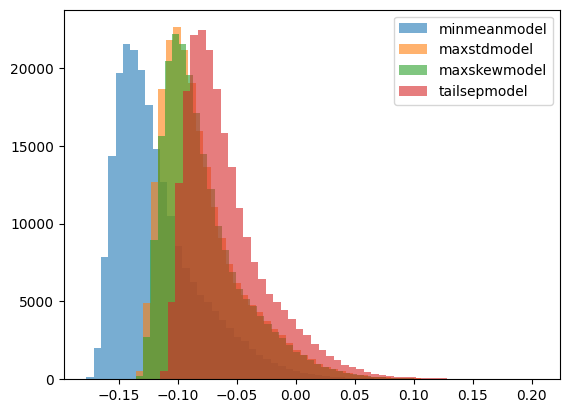

In [21]:
plt.hist(scores['meaniso'],bins=50,label='minmeanmodel',alpha=0.6)
plt.hist(scores['stdiso'],bins=50,label='maxstdmodel',alpha=0.6)
plt.hist(scores['skewiso'],bins=50,label='maxskewmodel',alpha=0.6)
plt.hist(scores['tailsepiso'],bins=50,label='tailsepmodel',alpha=0.6)

plt.legend()
plt.show()

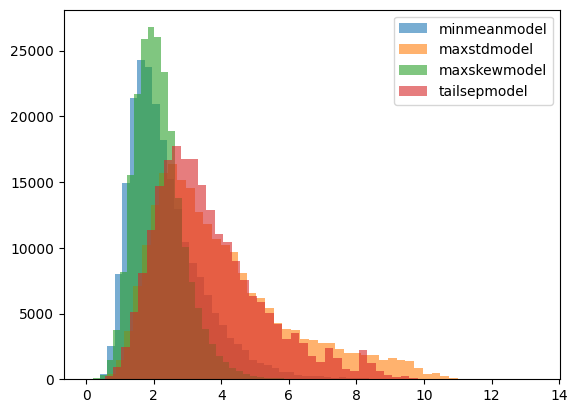

In [23]:
plt.hist(scores['meansom'],bins=50,label='minmeanmodel',alpha=0.6)
plt.hist(scores['stdsom'],bins=50,label='maxstdmodel',alpha=0.6)
plt.hist(scores['skewsom'],bins=50,label='maxskewmodel',alpha=0.6)
plt.hist(scores['tailsepsom'],bins=50,label='tailsepmodel',alpha=0.6)

plt.legend()
plt.show()

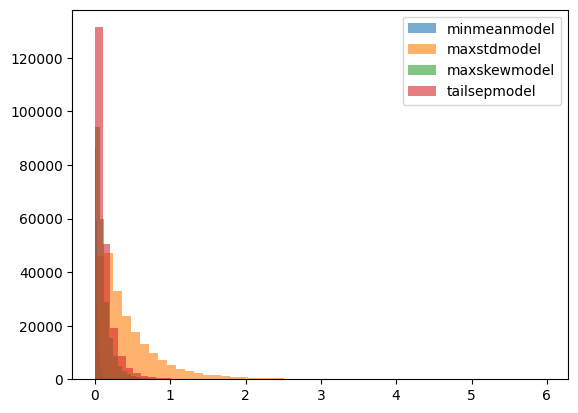

In [25]:
plt.hist(scores['meanae'],bins=50,label='minmeanmodel',alpha=0.6)
plt.hist(scores['stdae'],bins=50,label='maxstdmodel',alpha=0.6)
plt.hist(scores['skewae'],bins=50,label='maxskewmodel',alpha=0.6)
plt.hist(scores['tailsepae'],bins=50,label='tailsepmodel',alpha=0.6)

plt.legend()
plt.show()